<a href="https://colab.research.google.com/github/Abdulkhabeer70/Face_Mask_Detection/blob/main/01_EDA_and_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1: Exploratory Data Analysis & Preprocessing

## Face Mask Detection Project

**Dataset:** Kaggle Face Mask Dataset by Omkar Gurav  
**Description:** 7,553 RGB images (3,725 with mask, 3,828 without mask) at variable resolutions.  

### Objectives of this Notebook:
1. Download and set up the dataset from Kaggle
2. Perform exploratory data analysis (class distribution, resolution statistics)
3. Visualize sample images from both classes
4. Preprocess images (resize, normalize, label encoding)
5. Split data into train/validation/test sets (70/15/15)
6. Apply and visualize data augmentation strategies
7. Save preprocessed data for subsequent model training notebooks

---

## 1. Environment Setup & Dataset Download

This section handles:
- Mounting Google Drive for persistent storage
- Installing the Kaggle CLI tool
- Configuring API credentials for authenticated dataset download
- Downloading and extracting the Face Mask Dataset

**Note:** You must upload your `kaggle.json` API key file when prompted. You can obtain this file from your Kaggle account settings at https://www.kaggle.com/settings.

In [1]:
# ============================================================
# 1.1 Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/Face_Mask_Detection'
os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)
os.makedirs(os.path.join(DRIVE_PROJECT_DIR, 'data'), exist_ok=True)
os.makedirs(os.path.join(DRIVE_PROJECT_DIR, 'models'), exist_ok=True)
print(f"Project directory: {DRIVE_PROJECT_DIR}")

Mounted at /content/drive
Project directory: /content/drive/MyDrive/Face_Mask_Detection


In [2]:
# ============================================================
# 1.2 Install Kaggle CLI & Configure API Key
# ============================================================

!pip install -q kaggle

from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API key configured successfully!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle API key configured successfully!


In [3]:
# ============================================================
# 1.3 Download and Extract Dataset
# ============================================================

!kaggle datasets download -d omkargurav/face-mask-dataset -p /content/

import zipfile
with zipfile.ZipFile('/content/face-mask-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/data/')

print("Dataset downloaded and extracted!")

# Show what was extracted
for root, dirs, files_list in os.walk('/content/data/'):
    level = root.replace('/content/data/', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files_list[:3]:
            print(f"{subindent}{f}")
        if len(files_list) > 3:
            print(f"{subindent}... and {len(files_list) - 3} more files")

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:00<00:00, 199MB/s]

Dataset downloaded and extracted!
/
data/
  with_mask/
    with_mask_794.jpg
    with_mask_26.jpg
    with_mask_3120.jpg
    ... and 3722 more files
  without_mask/
    without_mask_2396.jpg
    without_mask_1520.jpg
    without_mask_44.jpg
    ... and 3825 more files


## 2. Import Libraries

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from PIL import Image
import cv2
import os
import glob
import random
import gc

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Dataset Overview & Class Distribution

Before any modeling, it is essential to understand the dataset composition. We examine:
- **Class distribution**: Number of images per class. An imbalanced dataset can bias models.
- **Total dataset size**: Helps determine model complexity and augmentation needs.

A well-balanced dataset simplifies training since we don't need class weighting or oversampling.

In [5]:
# ============================================================
# 3. Dataset Overview — Auto-detect paths
# ============================================================

DATA_DIR = None
for root, dirs, _files in os.walk('/content/data/'):
    if 'with_mask' in dirs and 'without_mask' in dirs:
        DATA_DIR = root
        break

if DATA_DIR is None:
    for candidate in ['/content/data/data', '/content/data',
                      '/content/data/face-mask-dataset',
                      '/content/data/face-mask-dataset/data']:
        if os.path.isdir(os.path.join(candidate, 'with_mask')):
            DATA_DIR = candidate
            break

if DATA_DIR is None:
    print("ERROR: Could not find with_mask/without_mask folders!")
    !find /content/data -type d
    raise FileNotFoundError('Update DATA_DIR manually based on output above.')

print(f'Dataset root: {DATA_DIR}')

MASK_DIR = os.path.join(DATA_DIR, 'with_mask')
NO_MASK_DIR = os.path.join(DATA_DIR, 'without_mask')

valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff'}

mask_images = [f for f in os.listdir(MASK_DIR)
               if os.path.splitext(f)[1].lower() in valid_extensions]
no_mask_images = [f for f in os.listdir(NO_MASK_DIR)
                  if os.path.splitext(f)[1].lower() in valid_extensions]

n_mask = len(mask_images)
n_no_mask = len(no_mask_images)
n_total = n_mask + n_no_mask

print(f'\nWith mask:    {n_mask:,}')
print(f'Without mask: {n_no_mask:,}')
print(f'Total:        {n_total:,}')
print(f'Balance:      {n_mask/n_total*100:.1f}% / {n_no_mask/n_total*100:.1f}%')

Dataset root: /content/data/data

With mask:    3,725
Without mask: 3,828
Total:        7,553
Balance:      49.3% / 50.7%


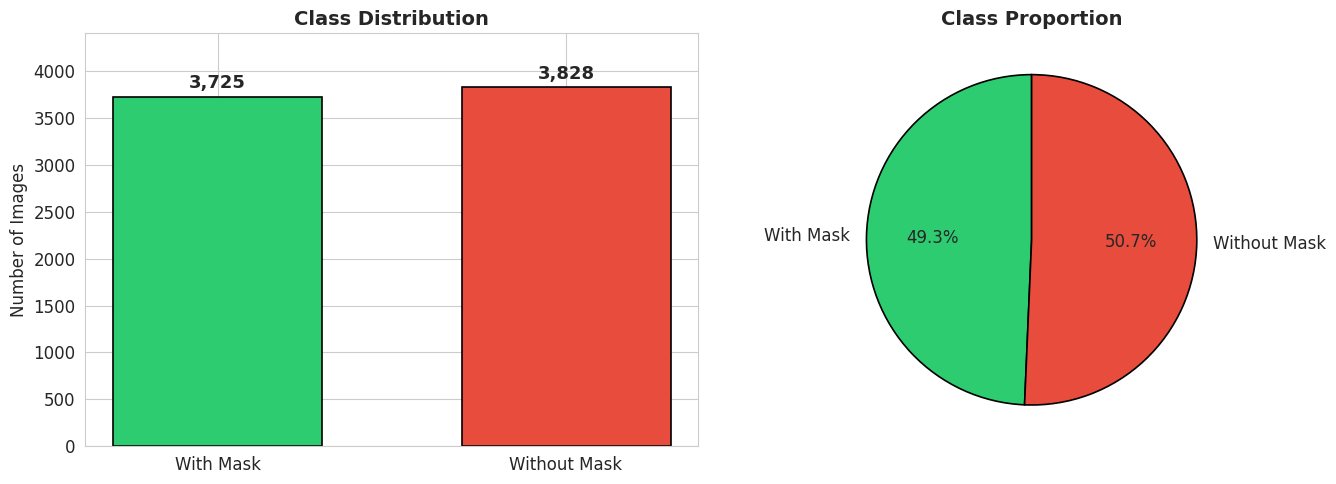

In [6]:
# ============================================================
# 3.1 Class Distribution Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes = ['With Mask', 'Without Mask']
counts = [n_mask, n_no_mask]
colors = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(classes, counts, color=colors, edgecolor='black', linewidth=1.2, width=0.6)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=13)

axes[1].pie(counts, labels=classes, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Resolution Analysis

Since this dataset contains images at **variable resolutions**, understanding the distribution of image sizes is crucial for:
- **Choosing a target resize dimension**: Too small loses detail; too large wastes computation.
- **Understanding aspect ratios**: Severe distortion from resizing can hurt performance.
- **Identifying outliers**: Extremely small or large images may need special handling.

In [7]:
# ============================================================
# 4. Resolution Analysis
# ============================================================

widths, heights, aspect_ratios = [], [], []
corrupted_files = []

all_image_paths = (
    [(os.path.join(MASK_DIR, f), 'with_mask') for f in mask_images] +
    [(os.path.join(NO_MASK_DIR, f), 'without_mask') for f in no_mask_images]
)

print("Analyzing image resolutions...")
for img_path, label in all_image_paths:
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
    except Exception as e:
        corrupted_files.append((img_path, str(e)))

widths = np.array(widths)
heights = np.array(heights)
aspect_ratios = np.array(aspect_ratios)

print(f"Analyzed: {len(widths):,} images")
if corrupted_files:
    print(f"Corrupted: {len(corrupted_files)}")

print(f"\n{'Metric':<12} {'Width':>8} {'Height':>8}")
print(f"{'─' * 30}")
print(f"{'Min':<12} {widths.min():>8} {heights.min():>8}")
print(f"{'Max':<12} {widths.max():>8} {heights.max():>8}")
print(f"{'Mean':<12} {widths.mean():>8.1f} {heights.mean():>8.1f}")
print(f"{'Median':<12} {np.median(widths):>8.1f} {np.median(heights):>8.1f}")

Analyzing image resolutions...
Analyzed: 7,553 images

Metric          Width   Height
──────────────────────────────
Min                26       37
Max              5760     5412
Mean            259.6    268.9
Median          204.0    225.0


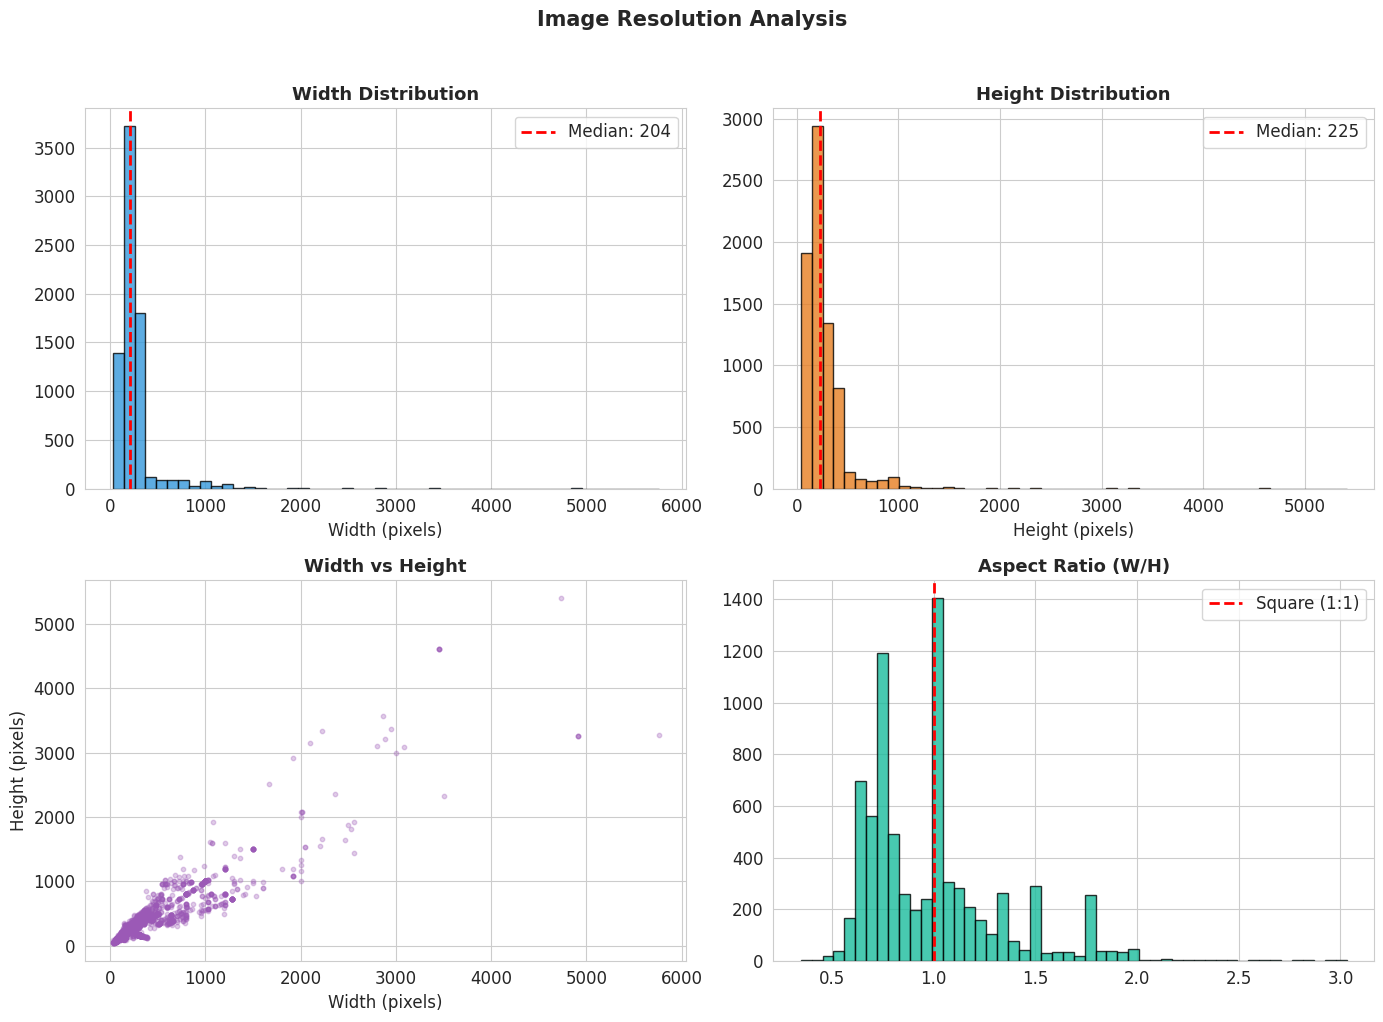

12

In [8]:
# ============================================================
# 4.1 Resolution Distribution Plots
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(widths, bins=50, color='#3498db', edgecolor='black', alpha=0.8)
axes[0, 0].axvline(x=np.median(widths), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(widths):.0f}')
axes[0, 0].set_title('Width Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Width (pixels)')
axes[0, 0].legend()

axes[0, 1].hist(heights, bins=50, color='#e67e22', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(x=np.median(heights), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(heights):.0f}')
axes[0, 1].set_title('Height Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Height (pixels)')
axes[0, 1].legend()

axes[1, 0].scatter(widths, heights, alpha=0.3, s=10, color='#9b59b6')
axes[1, 0].set_title('Width vs Height', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Width (pixels)')
axes[1, 0].set_ylabel('Height (pixels)')

axes[1, 1].hist(aspect_ratios, bins=50, color='#1abc9c', edgecolor='black', alpha=0.8)
axes[1, 1].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Square (1:1)')
axes[1, 1].set_title('Aspect Ratio (W/H)', fontsize=13, fontweight='bold')
axes[1, 1].legend()

plt.suptitle('Image Resolution Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Free resolution data
del widths, heights, aspect_ratios, all_image_paths
gc.collect()

## 5. Sample Visualization

Visual inspection of sample images helps us verify data quality, understand image characteristics, and inform preprocessing decisions.

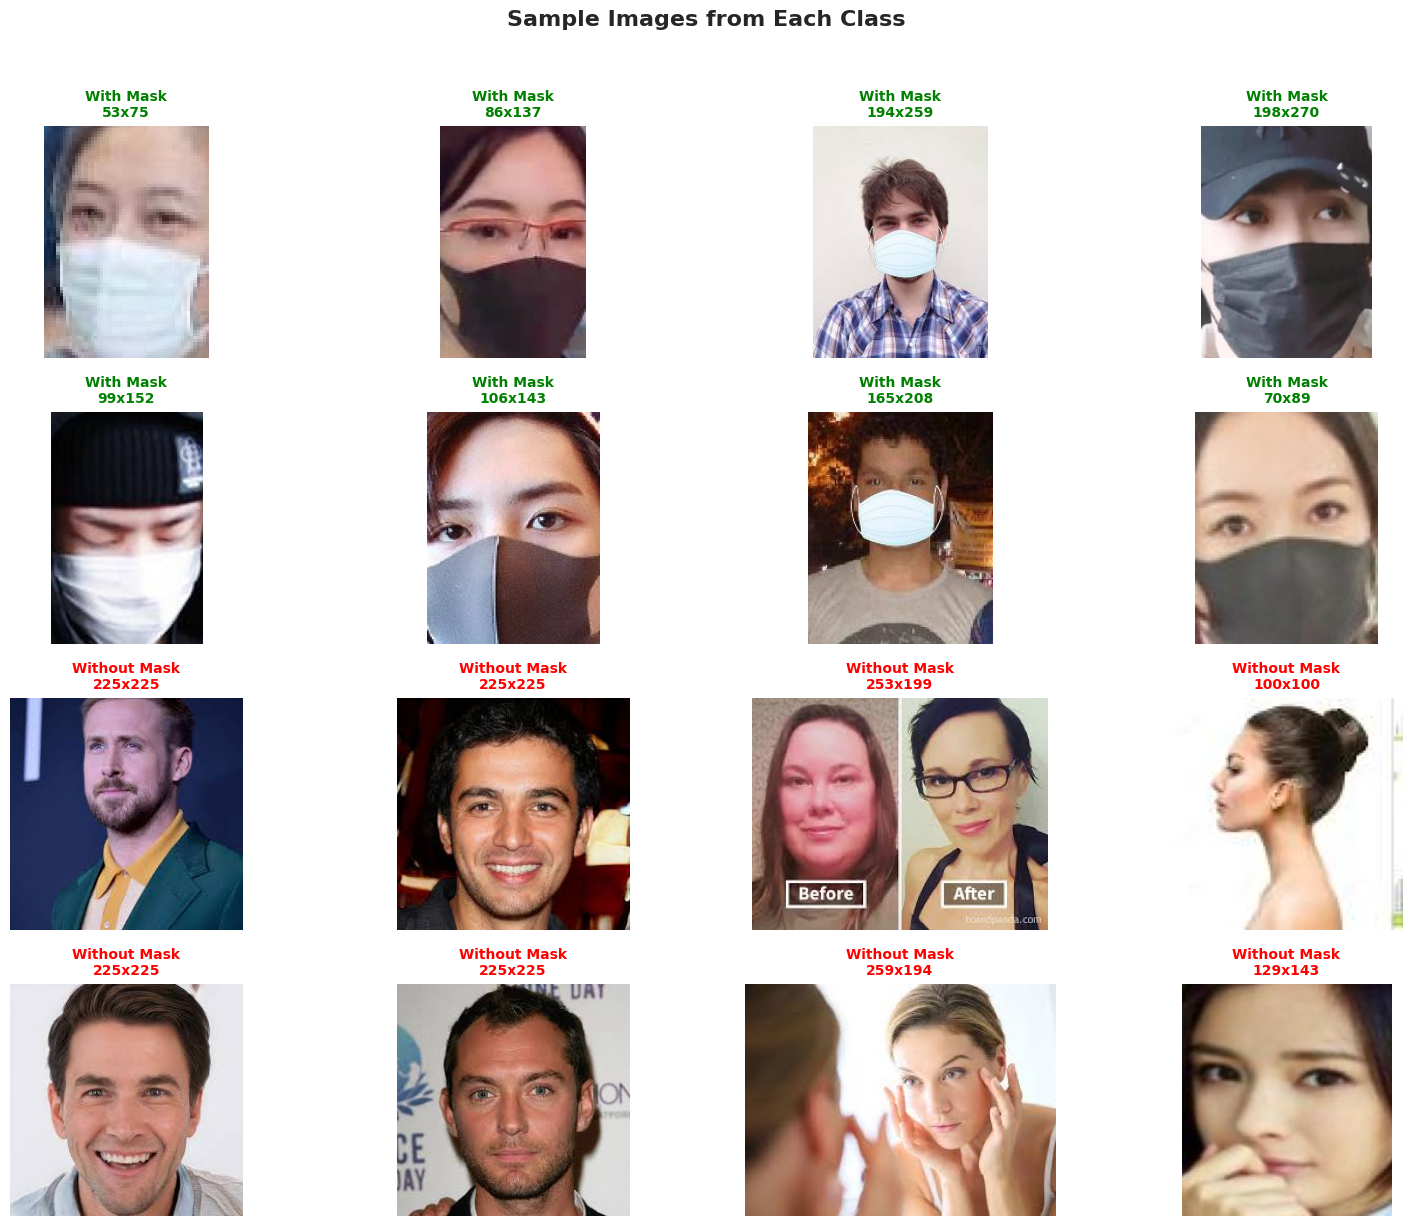

In [9]:
# ============================================================
# 5. Sample Image Visualization (4x4 Grid)
# ============================================================

fig, axes = plt.subplots(4, 4, figsize=(16, 12))

mask_samples = random.sample(mask_images, 8)
no_mask_samples = random.sample(no_mask_images, 8)

for i in range(8):
    row, col = i // 4, i % 4
    img = Image.open(os.path.join(MASK_DIR, mask_samples[i]))
    axes[row, col].imshow(img)
    axes[row, col].set_title(f'With Mask\n{img.size[0]}x{img.size[1]}',
                             fontsize=10, color='green', fontweight='bold')
    axes[row, col].axis('off')

for i in range(8):
    row, col = (i // 4) + 2, i % 4
    img = Image.open(os.path.join(NO_MASK_DIR, no_mask_samples[i]))
    axes[row, col].imshow(img)
    axes[row, col].set_title(f'Without Mask\n{img.size[0]}x{img.size[1]}',
                             fontsize=10, color='red', fontweight='bold')
    axes[row, col].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Image Preprocessing (Memory-Efficient)

Neural networks require fixed-size inputs. Our preprocessing pipeline:

1. **Resize to 224×224**: Standard input size for VGG, ResNet, MobileNet architectures
2. **Normalize to [0, 1]**: Faster convergence and numerical stability
3. **Label encoding**: 0 = without_mask, 1 = with_mask
4. **Stratified splitting (70/15/15)**: Maintains class proportions

> **Memory optimization**: We pre-allocate the NumPy array and load images directly into it,
> avoiding the need for a temporary Python list (which would double RAM usage).
> We also normalize in-place with `X /= 255.0` to avoid creating a copy.

In [10]:
# ============================================================
# 6.1 Load and Preprocess All Images (Memory-Efficient)
# ============================================================
# KEY OPTIMIZATION: Pre-allocate array instead of using a list.
# A Python list of arrays + np.array() conversion = 2x RAM usage.
# Pre-allocation uses only 1x RAM (~4.3 GB for 7553 images at 224x224x3 float32).

IMG_SIZE = 224

# Build the full file list with labels
all_files = (
    [(os.path.join(MASK_DIR, f), 1) for f in mask_images] +
    [(os.path.join(NO_MASK_DIR, f), 0) for f in no_mask_images]
)
n_total = len(all_files)

print(f"Loading {n_total:,} images at {IMG_SIZE}x{IMG_SIZE}...")
print(f"Expected memory: ~{n_total * IMG_SIZE * IMG_SIZE * 3 * 4 / (1024**3):.1f} GB")

# Pre-allocate arrays (single allocation, no copy needed later)
X = np.zeros((n_total, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
y = np.zeros(n_total, dtype=np.float32)

failed = 0
idx = 0  # tracks successful loads

for i, (img_path, label) in enumerate(all_files):
    try:
        img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        X[idx] = img_to_array(img)  # loads directly into pre-allocated array
        y[idx] = label
        idx += 1
    except Exception:
        failed += 1
    if (i + 1) % 1000 == 0:
        print(f"  Processed {i + 1:,}/{n_total:,} images...")

# Trim if any images failed
if idx < n_total:
    X = X[:idx]
    y = y[:idx]
    print(f"\n⚠ {failed} images failed to load. Using {idx:,} images.")

# Free the file list
del all_files
gc.collect()

# Normalize in-place (no copy — saves ~4 GB RAM!)
X /= 255.0

print(f"\n{'=' * 50}")
print("PREPROCESSED DATA SUMMARY")
print(f"{'=' * 50}")
print(f"Shape: {X.shape}")
print(f"Pixel range: [{X.min():.3f}, {X.max():.3f}]")
print(f"Memory: {X.nbytes / (1024**3):.2f} GB")
print(f"Without mask (0): {int(np.sum(y == 0)):,}")
print(f"With mask    (1): {int(np.sum(y == 1)):,}")

Loading 7,553 images at 224x224...
Expected memory: ~4.2 GB


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Processed 1,000/7,553 images...
  Processed 2,000/7,553 images...
  Processed 3,000/7,553 images...
  Processed 4,000/7,553 images...
  Processed 5,000/7,553 images...
  Processed 6,000/7,553 images...
  Processed 7,000/7,553 images...

PREPROCESSED DATA SUMMARY
Shape: (7553, 224, 224, 3)
Pixel range: [0.000, 1.000]
Memory: 4.24 GB
Without mask (0): 3,828
With mask    (1): 3,725


In [11]:
# ============================================================
# 6.2 Stratified Train/Validation/Test Split (70/15/15)
# ============================================================
# We split by INDICES first to avoid copying the full array,
# then extract subarrays. This is more memory-efficient.

from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
indices = np.arange(len(y))
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, random_state=42, stratify=y
)

# Second split: temp -> 50/50 = val + test (each 15% of total)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=42, stratify=y[temp_idx]
)

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

# Free the original full array to save RAM
del X, y, indices, temp_idx, train_idx, val_idx, test_idx
gc.collect()

print(f"{'Split':<12} {'Shape':<25} {'Mask':>6} {'NoMask':>8} {'Total':>7}")
print(f"{'─' * 60}")
print(f"{'Train':<12} {str(X_train.shape):<25} {int(y_train.sum()):>6} {int((y_train==0).sum()):>8} {len(y_train):>7}")
print(f"{'Validation':<12} {str(X_val.shape):<25} {int(y_val.sum()):>6} {int((y_val==0).sum()):>8} {len(y_val):>7}")
print(f"{'Test':<12} {str(X_test.shape):<25} {int(y_test.sum()):>6} {int((y_test==0).sum()):>8} {len(y_test):>7}")
print(f"\nTrain={len(y_train)/n_total*100:.1f}%, Val={len(y_val)/n_total*100:.1f}%, Test={len(y_test)/n_total*100:.1f}%")

Split        Shape                       Mask   NoMask   Total
────────────────────────────────────────────────────────────
Train        (5287, 224, 224, 3)         2607     2680    5287
Validation   (1133, 224, 224, 3)          559      574    1133
Test         (1133, 224, 224, 3)          559      574    1133

Train=70.0%, Val=15.0%, Test=15.0%


## 7. Data Augmentation

Data augmentation artificially increases training diversity by applying random transformations:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `rotation_range` | 15° | Faces can be slightly tilted |
| `width_shift_range` | 0.1 | Faces may not always be centered |
| `height_shift_range` | 0.1 | Vertical position variation |
| `horizontal_flip` | True | Faces are symmetric |
| `zoom_range` | 0.1 | Varying distance from camera |
| `brightness_range` | [0.8, 1.2] | Different lighting conditions |
| `shear_range` | 0.1 | Minor perspective variations |

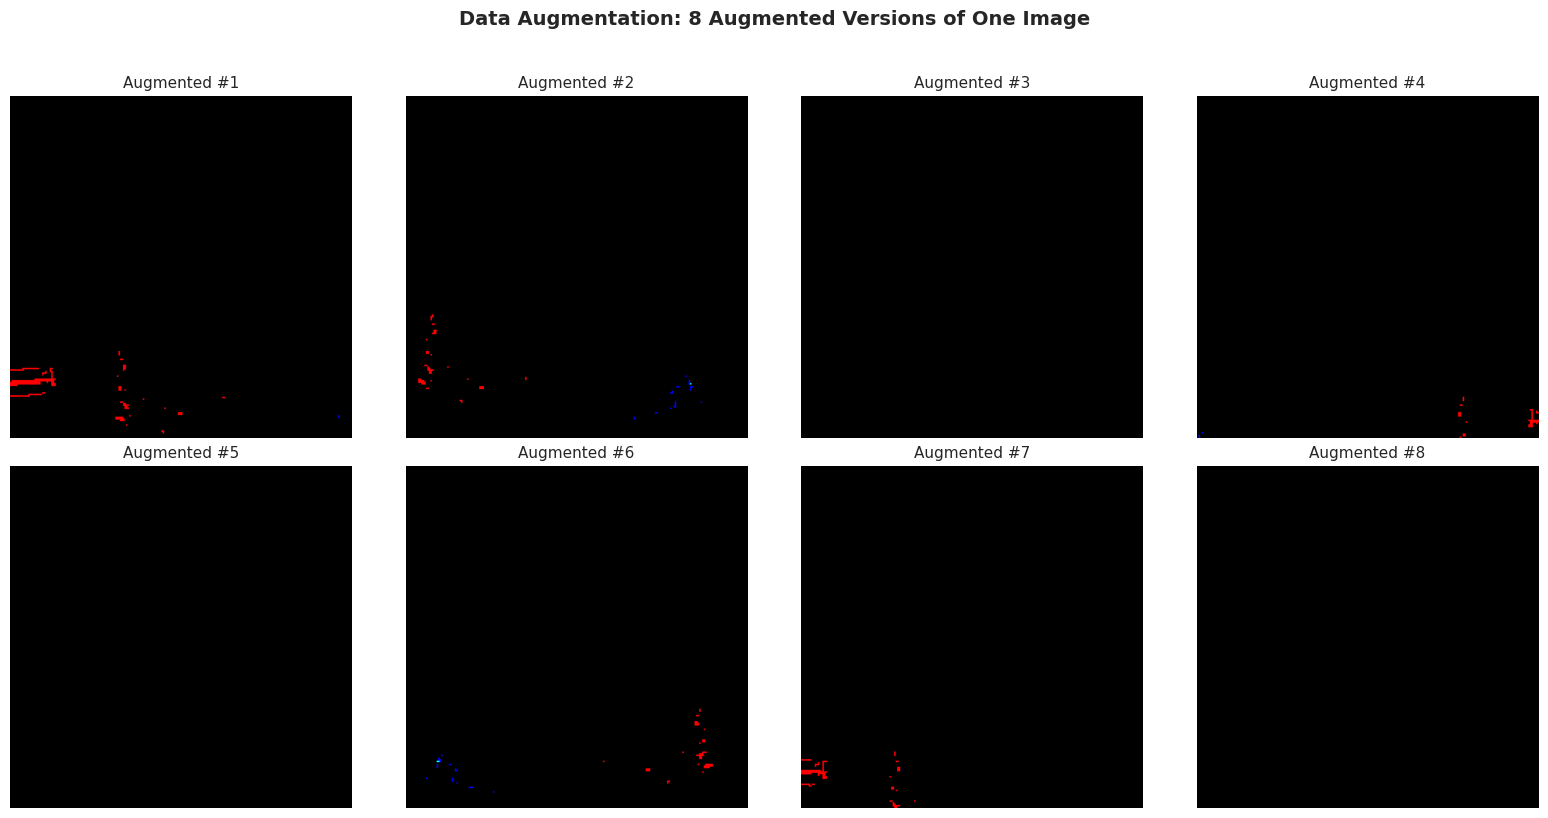

Augmentation pipeline configured successfully.


In [12]:
# ============================================================
# 7. Data Augmentation
# ============================================================

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    fill_mode='nearest'
)

# Visualize 8 augmented versions of a single image
sample_img = X_train[0]
sample_img_expanded = np.expand_dims(sample_img, 0)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Data Augmentation: 8 Augmented Versions of One Image',
             fontsize=14, fontweight='bold', y=1.02)

aug_iter = train_datagen.flow(sample_img_expanded, batch_size=1)
for i in range(8):
    row, col = i // 4, i % 4
    aug_img = np.clip(next(aug_iter)[0], 0, 1)
    axes[row, col].imshow(aug_img)
    axes[row, col].set_title(f'Augmented #{i+1}', fontsize=11)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()
print("Augmentation pipeline configured successfully.")

## 8. Save Preprocessed Data to Google Drive

We save the preprocessed arrays as `.npy` files to Google Drive to:
- Skip preprocessing in subsequent notebooks
- Ensure all models use the exact same data splits
- Save time on re-runs

In [13]:
# ============================================================
# 8. Save Preprocessed Data
# ============================================================

SAVE_DIR = os.path.join(DRIVE_PROJECT_DIR, 'data')

print("Saving to Google Drive...")
print(f"Directory: {SAVE_DIR}\n")

for name, arr in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test),
                  ('y_train', y_train), ('y_val', y_val), ('y_test', y_test)]:
    path = os.path.join(SAVE_DIR, f'{name}.npy')
    np.save(path, arr)
    size_mb = os.path.getsize(path) / (1024**2)
    print(f"  ✓ {name:<8} {str(arr.shape):<25} {size_mb:>8.1f} MB")

print(f"\n✅ All data saved successfully!")
print(f"📁 Location: {SAVE_DIR}")

Saving to Google Drive...
Directory: /content/drive/MyDrive/Face_Mask_Detection/data

  ✓ X_train  (5287, 224, 224, 3)         3035.9 MB
  ✓ X_val    (1133, 224, 224, 3)          650.6 MB
  ✓ X_test   (1133, 224, 224, 3)          650.6 MB
  ✓ y_train  (5287,)                        0.0 MB
  ✓ y_val    (1133,)                        0.0 MB
  ✓ y_test   (1133,)                        0.0 MB

✅ All data saved successfully!
📁 Location: /content/drive/MyDrive/Face_Mask_Detection/data


---

## Summary

1. **Dataset Download**: Downloaded Face Mask Dataset from Kaggle (7,553 images)
2. **Class Distribution**: Near-balanced (~49.3% mask, ~50.7% no mask)
3. **Resolution Analysis**: Variable dimensions, standardized to 224×224
4. **Sample Visualization**: Inspected representative images from both classes
5. **Preprocessing**: Resized, normalized to [0,1], binary labels
6. **Data Splitting**: Stratified 70/15/15 train/validation/test splits
7. **Data Augmentation**: Configured augmentation pipeline
8. **Data Persistence**: Saved all arrays to Google Drive

**Next Steps**: Proceed to Notebook 2 for building and training a Custom CNN architecture.